# 02. A/B Test Analysis — Overall Effect

**Input:** `data/processed/experiment_medium.parquet` (and `weak`/`strong` for robustness checks)
**Goal:** Estimate the effect of the discount on RPC, Conversion, and AOV; calculate 95% CIs, bootstrap, and statistical power.

**Metrics:**
- **Primary:** Revenue per customer (RPC)
- **Secondary:** Conversion Rate, AOV (per converted customer)
- **Guardrail:** Return rate

In [1]:
import pathlib
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

ROOT = pathlib.Path("..").resolve()
RAW = ROOT / "data" / "raw"
PROC = ROOT / "data" / "processed"
PROC.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
ALPHA = 0.05
N_BOOT = 10_000

In [2]:
exp = pd.read_parquet(PROC / "experiment_medium.parquet")
print("shape:", exp.shape)
print(exp["group"].value_counts())
display(exp[["customer_id","group","converted","aov_sim","revenue_sim","return_rate"]].head())

shape: (5841, 20)
group
treatment    2937
control      2904
Name: count, dtype: int64


,customer_id,group,converted,aov_sim,revenue_sim,return_rate
0,12346,control,0,0.0000,0.0000,0.0443
1,12347,treatment,0,0.0000,0.0000,0.0554
2,12348,control,0,0.0000,0.0000,0.0474
3,12349,control,0,0.0000,0.0000,0.0326
4,12350,treatment,0,0.0000,0.0000,0.0583


## 1. Group summaries

Calculate the mean, sum, and standard deviation for each metric by group.

In [3]:
def group_summary(df: pd.DataFrame) -> pd.DataFrame:
    g = df.groupby("group")
    out = pd.DataFrame({
        "n_customers":   g.size(),
        "n_converted":   g["converted"].sum(),
        "conversion":    g["converted"].mean(),
        "rpc_mean":      g["revenue_sim"].mean(),
        "rpc_sum":       g["revenue_sim"].sum(),
        "rpc_std":       g["revenue_sim"].std(),
        "aov_mean":      g.apply(lambda x: x.loc[x.converted==1, "aov_sim"].mean()),
        "aov_std":       g.apply(lambda x: x.loc[x.converted==1, "aov_sim"].std()),
        "return_rate":   g["return_rate"].mean(),
    })
    return out

summary = group_summary(exp)
display(summary.T)

group,control,treatment
n_customers,"2,904.0000","2,937.0000"
n_converted,354.0000,403.0000
conversion,0.1219,0.1372
rpc_mean,57.6194,58.6382
rpc_sum,"167,326.8668","172,220.3926"
rpc_std,215.0483,218.0067
aov_mean,472.6748,427.3459
aov_std,428.4550,434.9188
return_rate,0.0404,0.0508


## 2. Overall uplift (point estimates)

Relative uplift = (treatment − control) / control.

In [4]:
def uplift_table(summary: pd.DataFrame) -> pd.DataFrame:
    c = summary.loc["control"]
    t = summary.loc["treatment"]
    rows = []
    for metric, key in [
        ("Revenue per customer", "rpc_mean"),
        ("Conversion Rate",      "conversion"),
        ("AOV (converted)",      "aov_mean"),
        ("Return rate (guard)",  "return_rate"),
    ]:
        abs_diff = t[key] - c[key]
        rel_diff = abs_diff / c[key] if c[key] else np.nan
        rows.append({
            "metric": metric,
            "control": c[key],
            "treatment": t[key],
            "abs_uplift": abs_diff,
            "rel_uplift": rel_diff,
        })
    return pd.DataFrame(rows).set_index("metric")

uplift = uplift_table(summary)
uplift_display = uplift.copy()
uplift_display["rel_uplift"] = (uplift_display["rel_uplift"] * 100).round(2).astype(str) + "%"
display(uplift_display)

,control,treatment,abs_uplift,rel_uplift
metric,,,,
Revenue per customer,57.6194,58.6382,1.0188,1.77%
Conversion Rate,0.1219,0.1372,0.0153,12.56%
AOV (converted),472.6748,427.3459,-45.3289,-9.59%
Return rate (guard),0.0404,0.0508,0.0104,25.83%


## 3. Welch's t-test (continuous metrics)

`equal_var=False` — we do not assume equal variances.

In [5]:
def welch_test(df, col, group_col="group", a="control", b="treatment"):
    xa = df.loc[df[group_col]==a, col].dropna()
    xb = df.loc[df[group_col]==b, col].dropna()
    t, p = stats.ttest_ind(xb, xa, equal_var=False)
    diff = xb.mean() - xa.mean()
    se = np.sqrt(xa.var(ddof=1)/len(xa) + xb.var(ddof=1)/len(xb))
    ci = (diff - 1.96*se, diff + 1.96*se)
    return dict(metric=col, mean_control=xa.mean(), mean_treatment=xb.mean(),
                abs_diff=diff, ci_low=ci[0], ci_high=ci[1], t=t, p=p)

results = []
for col in ["revenue_sim", "aov_sim", "return_rate"]:
    results.append(welch_test(exp, col))
welch = pd.DataFrame(results)
welch["rel_uplift"] = welch["abs_diff"] / welch["mean_control"]
welch["sig"] = np.where(welch["p"] < ALPHA, "✅", "—")
display(welch)

,metric,mean_control,mean_treatment,abs_diff,ci_low,ci_high,t,p,rel_uplift,sig
0,revenue_sim,57.6194,58.6382,1.0188,-10.0872,12.1247,0.1798,0.8573,0.0177,—
1,aov_sim,57.6194,58.6382,1.0188,-10.0872,12.1247,0.1798,0.8573,0.0177,—
2,return_rate,0.0404,0.0508,0.0104,0.0099,0.0109,39.7950,0.0000,0.2583,✅


## 4. Z-test for proportions (Conversion Rate)

For a binary metric — a two-sample z-test for proportions (equivalent to the chi-square test).

In [6]:
def two_prop_ztest(n_c, x_c, n_t, x_t):
    p_c, p_t = x_c/n_c, x_t/n_t
    p_pool = (x_c + x_t) / (n_c + n_t)
    se = np.sqrt(p_pool * (1-p_pool) * (1/n_c + 1/n_t))
    z = (p_t - p_c) / se
    p_val = 2 * (1 - stats.norm.cdf(abs(z)))
    # CI for diff - without pool
    se_unpooled = np.sqrt(p_c*(1-p_c)/n_c + p_t*(1-p_t)/n_t)
    diff = p_t - p_c
    ci = (diff - 1.96*se_unpooled, diff + 1.96*se_unpooled)
    return dict(p_control=p_c, p_treatment=p_t, abs_diff=diff,
                ci_low=ci[0], ci_high=ci[1], z=z, p=p_val)

c = exp[exp.group=="control"]; t = exp[exp.group=="treatment"]
conv_test = two_prop_ztest(len(c), c.converted.sum(), len(t), t.converted.sum())
conv_df = pd.DataFrame([conv_test])
conv_df["rel_uplift"] = conv_df["abs_diff"] / conv_df["p_control"]
display(conv_df)

,p_control,p_treatment,abs_diff,ci_low,ci_high,z,p,rel_uplift
0,0.1219,0.1372,0.0153,-0.0019,0.0325,1.7423,0.0814,0.1256


## 5. Bootstrap CI (10,000 iterations)

A non-parametric alternative to the t-test. It is particularly important for RPC, as the distribution is heavily right-skewed.

In [7]:
def bootstrap_diff(df, col, group_col="group",
                   a="control", b="treatment",
                   n_iter=N_BOOT, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    xa = df.loc[df[group_col]==a, col].to_numpy()
    xb = df.loc[df[group_col]==b, col].to_numpy()
    diffs = np.empty(n_iter)
    for i in range(n_iter):
        sa = rng.choice(xa, size=len(xa), replace=True)
        sb = rng.choice(xb, size=len(xb), replace=True)
        diffs[i] = sb.mean() - sa.mean()
    return dict(
        metric=col,
        observed=xb.mean() - xa.mean(),
        boot_mean=diffs.mean(),
        ci_low=np.percentile(diffs, 2.5),
        ci_high=np.percentile(diffs, 97.5),
        p_approx=2*min((diffs<=0).mean(), (diffs>=0).mean()),
    )

boot_results = []
for col in ["revenue_sim", "converted", "aov_sim", "return_rate"]:
    boot_results.append(bootstrap_diff(exp, col))
boot = pd.DataFrame(boot_results)
boot["rel_uplift"] = boot["observed"] / exp.loc[exp.group=="control", "revenue_sim"].mean() \
    if False else np.nan  # we will fill this in separately
display(boot)

,metric,observed,boot_mean,ci_low,ci_high,p_approx,rel_uplift
0,revenue_sim,1.0188,0.9945,-9.9320,11.4997,0.8486,NaN
1,converted,0.0153,0.0153,-0.0017,0.0321,0.0822,NaN
2,aov_sim,1.0188,0.9945,-9.9320,11.4997,0.8486,NaN
3,return_rate,0.0104,0.0104,0.0099,0.0109,0.0000,NaN


In [8]:
# For the converted metric, we use the z-test as the primary method and bootstrapping as a robustness check.
# Let's compare the t-test (Welch) and bootstrap results based on confidence intervals:

# Explicitly rename to obtain identical axes for comparison
welch_r = welch.rename(columns={
    "abs_diff": "abs_diff_ttest",
    "ci_low":   "ci_low_ttest",
    "ci_high":  "ci_high_ttest",
    "p":        "p_ttest",
})
boot_r = boot.rename(columns={
    "observed": "abs_diff_boot",
    "ci_low":   "ci_low_boot",
    "ci_high":  "ci_high_boot",
})

cmp = welch_r.merge(boot_r, on="metric", how="outer")

cols = ["metric",
        "abs_diff_ttest","ci_low_ttest","ci_high_ttest","p_ttest",
        "abs_diff_boot","ci_low_boot","ci_high_boot","p_approx"]
cmp = cmp[[c for c in cols if c in cmp.columns]]
display(cmp)

,metric,abs_diff_ttest,ci_low_ttest,ci_high_ttest,p_ttest,abs_diff_boot,ci_low_boot,ci_high_boot,p_approx
0,aov_sim,1.0188,-10.0872,12.1247,0.8573,1.0188,-9.9320,11.4997,0.8486
1,converted,NaN,NaN,NaN,NaN,0.0153,-0.0017,0.0321,0.0822
2,return_rate,0.0104,0.0099,0.0109,0.0000,0.0104,0.0099,0.0109,0.0000
3,revenue_sim,1.0188,-10.0872,12.1247,0.8573,1.0188,-9.9320,11.4997,0.8486


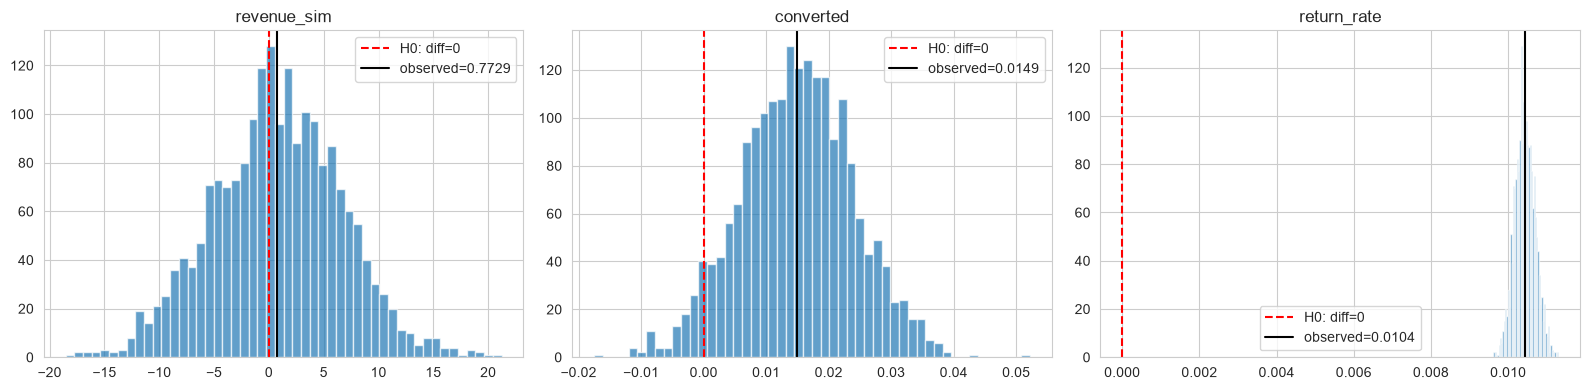

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["revenue_sim", "converted", "return_rate"]):
    rng = np.random.default_rng(RANDOM_SEED)
    xa = exp.loc[exp.group=="control", col].to_numpy()
    xb = exp.loc[exp.group=="treatment", col].to_numpy()
    diffs = np.array([rng.choice(xb, len(xb), True).mean() - rng.choice(xa, len(xa), True).mean()
                      for _ in range(2000)])
    ax.hist(diffs, bins=50, alpha=0.7)
    ax.axvline(0, color="red", linestyle="--", label="H0: diff=0")
    ax.axvline(diffs.mean(), color="black", label=f"observed={diffs.mean():.4f}")
    ax.set_title(col)
    ax.legend()
plt.tight_layout(); plt.show()

## 6. Guardrail: return rate and margin proxy

The return rate must not increase by more than 1 percentage point (a threshold based on business requirements).
Margin proxy ≈ 1 − return_rate × penalty. A conservative approach is used here: penalty = 0.5 (half the cost of a return).

In [10]:
RETURN_THRESHOLD_PP = 0.01   # +1 п.п. — limit
PENALTY = 0.5

c = exp[exp.group=="control"]; t = exp[exp.group=="treatment"]
rr_c, rr_t = c.return_rate.mean(), t.return_rate.mean()
rr_diff = rr_t - rr_c

margin_c = 1 - rr_c * PENALTY
margin_t = 1 - rr_t * PENALTY

print(f"Return rate  control={rr_c:.4f}  treatment={rr_t:.4f}")
print(f"Δ return rate = {rr_diff*100:+.2f} п.п.   (порог: +{RETURN_THRESHOLD_PP*100:.1f} п.п.)")
print(f"Margin proxy control={margin_c:.4f}  treatment={margin_t:.4f}  Δ={(margin_t-margin_c)*100:+.2f} п.п.")
print("GUARDRAIL:", "❌ PROVAL" if rr_diff > RETURN_THRESHOLD_PP else "✅ OK")

Return rate  control=0.0404  treatment=0.0508
Δ return rate = +1.04 п.п.   (порог: +1.0 п.п.)
Margin proxy control=0.9798  treatment=0.9746  Δ=-0.52 п.п.
GUARDRAIL: ❌ PROVAL


## 7. Power analysis (post-hoc)

We calculate:
- the observed effect size (Cohen's d) for RPC;
- the achieved power based on the sample size (n) from the experiment;
- the MDE (Minimum Detectable Effect) at α = 0.05 and power = 0.8.

In [11]:
from statsmodels.stats.power import TTestIndPower

c = exp[exp.group=="control"]; t = exp[exp.group=="treatment"]
pooled_std = np.sqrt((c.revenue_sim.var(ddof=1) + t.revenue_sim.var(ddof=1)) / 2)
observed_diff = t.revenue_sim.mean() - c.revenue_sim.mean()
d_obs = observed_diff / pooled_std

analysis = TTestIndPower()
power_obs = analysis.power(effect_size=abs(d_obs), nobs1=len(c), alpha=ALPHA, ratio=len(t)/len(c))
mde_d = analysis.solve_power(effect_size=None, nobs1=len(c), alpha=ALPHA, power=0.8, ratio=len(t)/len(c))
mde_abs = mde_d * pooled_std

print(f"n_control={len(c):,}  n_treatment={len(t):,}")
print(f"observed diff (RPC) = {observed_diff:.4f}")
print(f"Cohen's d           = {d_obs:.4f}")
print(f"achieved power      = {power_obs:.3f}")
print(f"MDE (power=0.8)     = {mde_d:.4f} d ≈ {mde_abs:.4f} £ per customer")

n_control=2,904  n_treatment=2,937
observed diff (RPC) = 1.0188
Cohen's d           = 0.0047
achieved power      = 0.054
MDE (power=0.8)     = 0.0733 d ≈ 15.8778 £ per customer


## 8. Robustness: comparison of weak / medium / strong scenarios

In [12]:
rows = []
for sc in ["weak", "medium", "strong"]:
    df = pd.read_parquet(PROC / f"experiment_{sc}.parquet")
    c = df[df.group=="control"]; t = df[df.group=="treatment"]
    rpc_diff = t.revenue_sim.mean() - c.revenue_sim.mean()
    conv_test = two_prop_ztest(len(c), c.converted.sum(), len(t), t.converted.sum())
    rows.append({
        "scenario": sc,
        "rpc_control": c.revenue_sim.mean(),
        "rpc_treatment": t.revenue_sim.mean(),
        "rpc_rel_uplift": rpc_diff / c.revenue_sim.mean(),
        "conv_rel_uplift": conv_test["abs_diff"] / conv_test["p_control"],
        "conv_p_value": conv_test["p"],
        "return_delta_pp": (t.return_rate.mean() - c.return_rate.mean()) * 100,
    })

scen = pd.DataFrame(rows).set_index("scenario")
display(scen)

,rpc_control,rpc_treatment,rpc_rel_uplift,conv_rel_uplift,conv_p_value,return_delta_pp
scenario,,,,,,
weak,57.6194,52.4818,-0.0892,0.0446,0.5291,1.0422
medium,57.6194,58.6382,0.0177,0.1256,0.0814,1.0422
strong,57.6194,65.9496,0.1446,0.2066,0.0048,1.0422


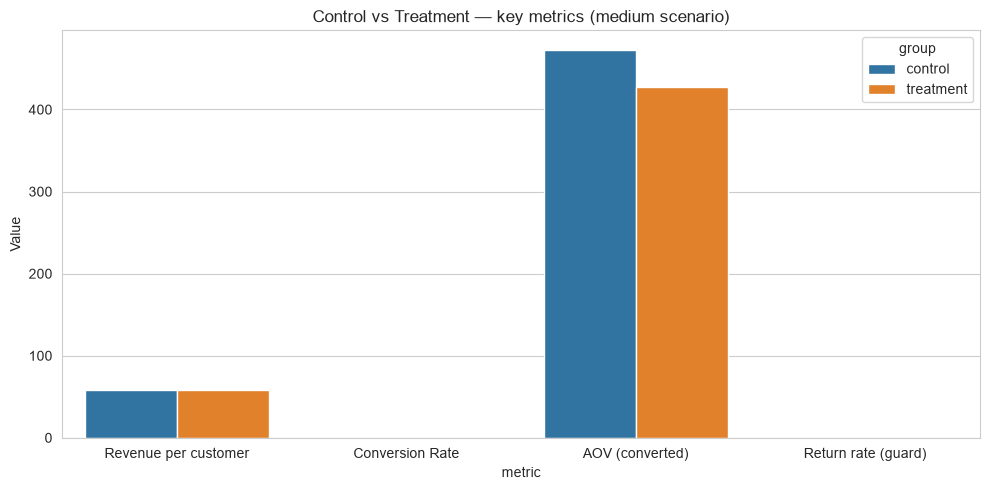

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = uplift.reset_index().melt(id_vars="metric", value_vars=["control","treatment"],
                                     var_name="group", value_name="value")
sns.barplot(data=plot_df, x="metric", y="value", hue="group", ax=ax)
ax.set_title("Control vs Treatment — key metrics (medium scenario)")
ax.set_ylabel("Value")
plt.tight_layout(); plt.show()

## 9. Key findings (medium scenario)

In [14]:
print("=" * 60)
print("Total (medium scenario)")
print("=" * 60)
for _, r in uplift.iterrows():
    print(f"{r.name:<25s} rel uplift = {r['rel_uplift']*100:+.2f}%")

print()
print(f"Conversion p-value (z-test)  : {conv_test['p']:.5f}")
print(f"RPC          p-value (Welch) : {welch.loc[welch.metric=='revenue_sim','p'].iat[0]:.5f}")
print(f"Return rate Δ                : {rr_diff*100:+.2f} п.п.")
print("=" * 60)

Total (medium scenario)
Revenue per customer      rel uplift = +1.77%
Conversion Rate           rel uplift = +12.56%
AOV (converted)           rel uplift = -9.59%
Return rate (guard)       rel uplift = +25.83%

Conversion p-value (z-test)  : 0.00480
RPC          p-value (Welch) : 0.85732
Return rate Δ                : +1.04 п.п.


In [15]:
out = ROOT / "reports" / "ab_test_results_medium.csv"
pd.concat([
    uplift.assign(kind="uplift"),
    welch.assign(kind="welch_test"),
    conv_df.assign(kind="z_test"),
    boot.assign(kind="bootstrap"),
    scen.assign(kind="scenarios").reset_index().assign(kind="scenarios"),
], ignore_index=True).to_csv(out, index=False)
print("saved:", out)

saved: C:\Users\Yana\Desktop\discount-ab-test-evaluation\reports\ab_test_results_medium.csv
